# NGC 1068 fluctuated Case 2: CPL + PL

Explicit NGC 4151-style spectral fitting and SED workflow.


In [1]:
from pathlib import Path
import json

import sys
UTILS_DIR = Path(r"/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN/Fluctuate_True")
if str(UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(UTILS_DIR))


import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from astromodels import Cutoff_powerlaw, Line, Model, PointSource, Powerlaw
from threeML import DataList, JointLikelihood

from cosipy.event_selection import GoodTimeInterval
from agn_cosi_fit_utils import (
    COSIPlugin, cosi_source_detection_ts, fit_cosi_exposure_from_results,
    load_agn_manifest_histograms, make_cosi_background_parameter,
    model_improvement_ts, open_spacecraft_history, save_agn_fit_summary,
    scale_spacecraft_livetime,
)
from agn_sed_ensemble import (
    classify_representative_sed, ensemble_summary_to_sed_dataframe,
    fit_representative_sed, run_or_load_manifest_sed_ensemble,
)

SED_KEV_TO_ERG = u.keV.to(u.erg)
KEV_TO_MEV = u.keV.to(u.MeV)
%matplotlib inline


20:39:30 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=117827;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=26125;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=166600;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=441340;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=894074;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=298703;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

20:39:30 INFO      Starting 3ML!                                                                     ]8;id=955981;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=466699;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=888901;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=366970;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=572870;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=756770;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=532149;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=95567;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=499024;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=23831;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=125701;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=299332;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=601620;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=895408;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

# Model and input files


In [2]:
MANIFEST_24M_PATH = Path(r"/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case2/NGC1068_Case2_CPL_PL_threshold_median_realization_24months.json")
MANIFEST_3M_PATH = None
BACKGROUND_PSEUDOCOUNT = 1e-12
SED_ENSEMBLE_RECOMPUTE = False
SED_ENSEMBLE_SEED_COUNT = 300
N_SED_BINS = 10

PLOT_DIR = Path(r"/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True")
FIT_SUMMARY_DIR = Path(r"/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True")
PLOT_DIR.mkdir(parents=True, exist_ok=True)
FIT_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
with MANIFEST_24M_PATH.open() as stream:
    manifest_24m = json.load(stream)
case = manifest_24m.get("resolved_case_at_threshold", manifest_24m.get("resolved_case"))
if case is None:
    raise KeyError("Manifest has no resolved spectral case")

required_realization_files = [
    Path(manifest_24m["source_expectation_file"]),
    Path(manifest_24m["median_data_file"]),
]
missing_realization_files = [path for path in required_realization_files if not path.exists()]
if missing_realization_files:
    missing_text = "\n".join(str(path) for path in missing_realization_files)
    raise FileNotFoundError(
        "The manifest exists, but its HDF5 realization files are missing. "
        "Rerun the corresponding NGC 1068 sensitivity notebook first:\n"
        + missing_text
    )

manifest_24m, source_expectation_24m, data_24m, background_24m = load_agn_manifest_histograms(
    MANIFEST_24M_PATH, manifest_24m["background_file_3m"], 24,
)
dr = manifest_24m["response_file"]

source_coord = SkyCoord(
    l=float(case["longitude_deg"]), b=float(case["latitude_deg"]),
    frame="galactic", unit="deg",
)
full_orientation = open_spacecraft_history(manifest_24m["orientation_file_3m"])
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord, full_orientation, float(case.get("fov_cut_deg", 60.0))*u.deg,
    earth_occ=False,
)
orientation_3m = full_orientation.apply_gti(source_gti)
orientation_24m = scale_spacecraft_livetime(orientation_3m, 8.0)

print("Description:", case["description"])
print("Representative seed:", manifest_24m["representative_seed"])
print("Source file:", manifest_24m["source_expectation_file"])
print("Data file:", manifest_24m["median_data_file"])


Description: NGC 1068 Case 2: thermal CPL Ec=128 keV plus PL tail
Representative seed: 107070
Source file: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case2/NGC1068_ec_128_DC4_COSI_cpl_pl_60_fovCut_24months_bestMedian_normNT_1p05_medianSeed_107070.hdf5
Data file: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/NGC1068_Case2/NGC1068_plus_bkg_ec_128_DC4_COSI_cpl_pl_60_fovCut_24months_bestMedian_normNT_1p05_medianSeed_107070.hdf5


# Source model


In [4]:
def repivot_k(specification, pivot_keV):
    return float(
        specification["K"]
        * (float(pivot_keV) / float(specification["pivot_keV"]))
        ** float(specification["index"])
    )

def make_shape(specification, *, fit, pivot_keV=None):
    kind = specification["kind"]
    pivot = float(specification["pivot_keV"] if pivot_keV is None else pivot_keV)
    normalization = repivot_k(specification, pivot)
    if kind == "cpl":
        shape = Cutoff_powerlaw()
        shape.xc.value = float(specification["cutoff_keV"])
        shape.xc.unit = u.keV
        if fit:
            shape.xc.min_value = float(specification.get("cutoff_min_keV", 100.0))
            shape.xc.max_value = float(specification.get("cutoff_max_keV", 10000.0))
            shape.xc.fix = not bool(specification.get("fit_cutoff_free", True))
    elif kind == "pl":
        shape = Powerlaw()
    else:
        raise ValueError(f"Unsupported component: {kind}")
    shape.K.value = normalization
    shape.K.unit = u.keV**-1 * u.cm**-2 * u.s**-1
    shape.piv.value = pivot
    shape.piv.unit = u.keV
    shape.index.value = float(specification["index"])
    if fit:
        shape.K.min_value = float(specification.get("K_min", 1e-10))
        shape.K.max_value = float(specification.get("K_max", 1.0))
        shape.index.min_value = float(specification.get("index_min", -5.0))
        shape.index.max_value = float(specification.get("index_max", 1.0))
        shape.index.fix = not bool(specification.get("fit_index_free", kind == "pl"))
    return shape

fit_pivot_keV = float(case.get("fit_pivot_keV", 200.0))
primary_injected = make_shape(case["primary"], fit=False)
secondary_injected = None
injected_shape = primary_injected
if case.get("secondary") is not None:
    secondary_injected = make_shape(case["secondary"], fit=False)
    injected_shape = primary_injected + secondary_injected

primary_fit = make_shape(case["primary"], fit=True, pivot_keV=fit_pivot_keV)
fit_shape = primary_fit
secondary_fit = None
link_function = None
if case.get("secondary") is not None:
    secondary_fit = make_shape(case["secondary"], fit=True, pivot_keV=fit_pivot_keV)
    fit_shape = primary_fit + secondary_fit

source_name = str(case.get("source_name", "NGC1068"))
source = PointSource(
    source_name, l=float(case["longitude_deg"]), b=float(case["latitude_deg"]),
    spectral_shape=fit_shape,
)
model = Model(source)
if secondary_fit is not None:
    injected_link_ratio = repivot_k(case["secondary"], fit_pivot_keV) / repivot_k(case["primary"], fit_pivot_keV)
    link_function = Line(a=0.0, b=injected_link_ratio)
    link_function.a.fix = True
    link_function.b.min_value = 0.0
    model.link(
        model[source_name].spectrum.main.composite.K_2,
        model[source_name].spectrum.main.composite.K_1,
        link_function,
    )
    print("Injected linked K ratio:", injected_link_ratio)

print(model.display())


Injected linked K ratio: 0.2200919565086528


Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (4):
--------------------

                                            value min_value max_value  \
NGC1068.spectrum.main.composite.K_1      0.000005       0.0      0.01   
NGC1068.spectrum.main.composite.xc_1        128.0      10.0    2000.0   
NGC1068...b                              0.220092       0.0      None   
NGC1068.spectrum.main.composite.index_2      -2.8      -5.0       1.0   

                                                   unit  
NGC1068.spectrum.main.composite.K_1      keV-1 s-1 cm-2  
NGC1068.spectrum.main.composite.xc_1                keV  
NGC1068...b                                              
NGC1068.spectrum.main.composite.index_2                  

Fixed parameters (6):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (1):
----------------------

               NGC1068.spectrum.main.composite.K_2
linked to      NGC1068.spectrum.main.composite.K_1
function                                      Line
current value                             0.000001
unit                               1 / (keV s cm2)


Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

None


# Spectral fitting

Fit the CPL-only reference once, then fit CPL+PL from the same five starting points used by the Case 2 sensitivity calculator. The lowest negative log-likelihood is retained and refitted with covariance estimation enabled.


In [5]:
def likelihood_nll(likelihood):
    statistic = likelihood.results.get_statistic_frame()["-log(likelihood)"]
    if "total" in statistic.index:
        return float(statistic.loc["total"])
    return float(statistic.sum())


def set_bounded_start(parameter, value):
    value = float(value)
    if parameter.min_value is not None:
        value = max(value, float(parameter.min_value))
    if parameter.max_value is not None:
        value = min(value, float(parameter.max_value))
    parameter.value = value


# Fit the nested CPL-only reference once. Its fitted parameters provide
# the starts for four of the five CPL+PL fits below.
primary_only_shape = make_shape(case["primary"], fit=True, pivot_keV=fit_pivot_keV)
primary_only_source = PointSource(
    source_name + "_primary_only",
    l=float(case["longitude_deg"]), b=float(case["latitude_deg"]),
    spectral_shape=primary_only_shape,
)
primary_only_model = Model(primary_only_source)
primary_only_plugin = COSIPlugin(
    "cosi_primary_only_24m", dr=dr,
    data=data_24m.project("Em", "Phi", "PsiChi"),
    bkg=background_24m.project("Em", "Phi", "PsiChi"),
    sc_orientation=orientation_24m,
    nuisance_param=make_cosi_background_parameter("cosi_primary_only_24m"),
    background_pseudocount=BACKGROUND_PSEUDOCOUNT, earth_occ=True,
)
primary_only_plugin.set_model(primary_only_model)
like_primary = JointLikelihood(
    primary_only_model, DataList(primary_only_plugin), verbose=False,
)
like_primary.fit()
primary_background_parameter = list(primary_only_plugin.nuisance_parameters.values())[0]
reference_start = {
    "primary_K": float(primary_only_shape.K.value),
    "primary_cutoff_keV": float(primary_only_shape.xc.value),
    "background_rate_hz": float(primary_background_parameter.value),
}

# Build one full-model plugin and reuse its already-computed response for
# every start. Each JointLikelihood call gets the explicitly reset values.
background_parameter = make_cosi_background_parameter("cosi_24m")
cosi = COSIPlugin(
    "cosi_24m", dr=dr,
    data=data_24m.project("Em", "Phi", "PsiChi"),
    bkg=background_24m.project("Em", "Phi", "PsiChi"),
    sc_orientation=orientation_24m, nuisance_param=background_parameter,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT, earth_occ=True,
)
cosi.set_model(model)
full_background_parameter = list(cosi.nuisance_parameters.values())[0]
default_background_start = float(full_background_parameter.value)

injected_primary_k = repivot_k(case["primary"], fit_pivot_keV)
injected_cutoff = float(case["primary"]["cutoff_keV"])
injected_tail_index = float(case["secondary"]["index"])

multi_start_definitions = [
    {
        "label": "injected_comp_start",
        "primary_K": injected_primary_k,
        "primary_cutoff_keV": injected_cutoff,
        "secondary_link_ratio": injected_link_ratio,
        "secondary_index": injected_tail_index,
        "background_rate_hz": default_background_start,
    },
]
for label, ratio_factor, tail_index in [
    ("nested_true_tail", 1.0, injected_tail_index),
    ("nested_half_steep", 0.5, -3.2),
    ("nested_double_shallow", 2.0, -2.4),
    ("nested_near_null", 1e-6, injected_tail_index),
]:
    multi_start_definitions.append({
        "label": label,
        **reference_start,
        "secondary_link_ratio": max(injected_link_ratio * ratio_factor, 1e-12),
        "secondary_index": tail_index,
    })

multi_start_results = []
multi_start_errors = []
trial_like = JointLikelihood(model, DataList(cosi), verbose=False)
for start in multi_start_definitions:
    set_bounded_start(primary_fit.K, start["primary_K"])
    set_bounded_start(primary_fit.xc, start["primary_cutoff_keV"])
    set_bounded_start(link_function.b, start["secondary_link_ratio"])
    set_bounded_start(secondary_fit.index, start["secondary_index"])
    set_bounded_start(full_background_parameter, start["background_rate_hz"])
    try:
        trial_like.fit(compute_covariance=False, quiet=True)
        result = {
            "label": start["label"],
            "nll": likelihood_nll(trial_like),
            "primary_K": float(primary_fit.K.value),
            "primary_cutoff_keV": float(primary_fit.xc.value),
            "secondary_link_ratio": float(link_function.b.value),
            "secondary_index": float(secondary_fit.index.value),
            "background_rate_hz": float(full_background_parameter.value),
        }
        multi_start_results.append(result)
        print(f"{result['label']}: -log(L) = {result['nll']:.6f}")
    except Exception as error:
        multi_start_errors.append(f"{start['label']}: {error!r}")
        print(f"{start['label']} failed: {error!r}")

if not multi_start_results:
    raise RuntimeError("All CPL+PL multi-start fits failed: " + "; ".join(multi_start_errors))

best_start = min(multi_start_results, key=lambda result: result["nll"])
selected_start_label = best_start["label"]
set_bounded_start(primary_fit.K, best_start["primary_K"])
set_bounded_start(primary_fit.xc, best_start["primary_cutoff_keV"])
set_bounded_start(link_function.b, best_start["secondary_link_ratio"])
set_bounded_start(secondary_fit.index, best_start["secondary_index"])
set_bounded_start(full_background_parameter, best_start["background_rate_hz"])

# Refit from the best minimum with covariance/error estimation enabled so
# all later plotting and summary cells continue to use standard results.
like = trial_like
like.fit()
final_full_nll = likelihood_nll(like)
TS_24m, null_24m = cosi_source_detection_ts(like, cosi)
print("Selected CPL+PL start:", selected_start_label)
print("Final full-model -log(L):", final_full_nll)
print("24-month source TS:", TS_24m)
display(like.results.get_data_frame())


20:39:57 INFO      set the minimizer to minuit                                             ]8;id=42296;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=62574;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

20:40:07 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=514495;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=269881;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

Best fit values:

,result,unit
parameter,,
NGC1068_primary_only...K,(5.9 +/- 0.5) x 10^-6,1 / (keV s cm2)
NGC1068_primary_only...xc,(2.06 -0.18 +0.20) x 10^2,keV
background_cosi_primary_only_24m,(2.48985 +/- 0.00015) x 10,Hz


Correlation matrix:

...

,-log(likelihood)
cosi_24m,-3787825257.811441
total,-3787825257.811441


Values of statistical measures:

,statistical measures
AIC,-7575650505.622622
BIC,-7575650453.885021


Selected CPL+PL start: injected_comp_start
Final full-model -log(L): -3787825257.811441
24-month source TS: 852.2005796432495


,value,negative_error,positive_error,error,unit
NGC1068.spectrum.main.composite.K_1,0.000005,-0.000002,0.000002,0.000002,1 / (keV s cm2)
NGC1068.spectrum.main.composite.xc_1,120.001878,-29.120536,39.067264,34.093900,keV
NGC1068.spectrum.main.composite.K_2.Line.b,0.269601,-0.120032,0.125881,0.122957,
NGC1068.spectrum.main.composite.index_2,-2.816570,-0.201429,0.190222,0.195826,
background_cosi_24m,24.896860,-0.001546,0.001599,0.001572,Hz


## Nested-model comparison


In [6]:
delta_ts_24m = None
if case.get("secondary") is not None:
    delta_ts_24m = model_improvement_ts(like_primary, like)
    print("Selected multi-start solution:", selected_start_label)
    print("Sensitivity ensemble median Delta TS:", manifest_24m.get("median_delta_ts_at_grid_threshold"))
    print("Sensitivity representative-seed Delta TS:", manifest_24m.get("representative_delta_ts"))
    print("24-month full model versus CPL-only Delta TS:", delta_ts_24m)


Selected multi-start solution: injected_comp_start
Sensitivity ensemble median Delta TS: 7.541369438171387
Sensitivity representative-seed Delta TS: 7.391352653503418
24-month full model versus CPL-only Delta TS: 7.391345024108887


## 24-month result


In [7]:
like_3m = None
TS_3m = None
delta_ts_3m = None
if MANIFEST_3M_PATH is not None:
    manifest_3m, source_expectation_3m, data_3m, background_3m = load_agn_manifest_histograms(
        MANIFEST_3M_PATH, manifest_24m["background_file_3m"], 3,
    )
    like_3m, cosi_3m = fit_cosi_exposure_from_results(
        reference_results=like.results, data_hist=data_3m, background_hist=background_3m,
        dr_path=dr, sc_orientation=orientation_3m, dataset_name="cosi_3m",
        background_pseudocount=BACKGROUND_PSEUDOCOUNT,
    )
    TS_3m, _ = cosi_source_detection_ts(like_3m, cosi_3m)
    print("3-month source TS:", TS_3m)
    if like_primary is not None:
        like_primary_3m, _ = fit_cosi_exposure_from_results(
            reference_results=like_primary.results, data_hist=data_3m, background_hist=background_3m,
            dr_path=dr, sc_orientation=orientation_3m, dataset_name="cosi_primary_only_3m",
            background_pseudocount=BACKGROUND_PSEUDOCOUNT,
        )
        delta_ts_3m = model_improvement_ts(like_primary_3m, like_3m)
        print("3-month full model versus CPL-only Delta TS:", delta_ts_3m)


In [8]:
fit_results = {"24m_case2": like.results}
injected_models = {"24m_case2": {"total": injected_shape}}
ts_values = {"24m_case2": TS_24m}
exposures = {"24m_case2": 24}
extra_statistics = {}
if delta_ts_24m is not None:
    extra_statistics["24m_case2"] = {"Delta_TS_full_vs_CPL": delta_ts_24m}
if like_3m is not None:
    fit_results["3m_case2"] = like_3m.results
    injected_models["3m_case2"] = {"total": injected_shape}
    ts_values["3m_case2"] = TS_3m
    exposures["3m_case2"] = 3
    if delta_ts_3m is not None:
        extra_statistics["3m_case2"] = {"Delta_TS_full_vs_CPL": delta_ts_3m}
fit_summary_path = save_agn_fit_summary(
    output_path=FIT_SUMMARY_DIR / "NGC1068_Case2_CPL_PL_global_fit_summary_24Months.txt",
    fit_results=fit_results, injected_models=injected_models,
    ts_values=ts_values, exposure_months=exposures,
    extra_statistics=extra_statistics,
    notes="Explicit NGC 4151-style fit using the exact zero-source null.",
)
print("Saved:", fit_summary_path)


Saved: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Fits/Fluctuate_True/NGC1068_Case2_CPL_PL_global_fit_summary_24Months.txt


## Global-fit plot


In [9]:
results = like.results
optimized_shape = results.optimized_model[source_name].spectrum.main.shape

def variate_or_value(parameter):
    if parameter.path in results.optimized_model.free_parameters:
        return results.get_variates(parameter.path)
    return float(parameter.value)

if optimized_shape.__class__.__name__ == "Cutoff_powerlaw":
    pivot = float(optimized_shape.piv.value)
    def evaluate_total(energy, K, xc, index):
        return K * (energy/pivot)**index * np.exp(-energy/xc)
    propagated_flux = results.propagate(
        evaluate_total, K=variate_or_value(optimized_shape.K),
        xc=variate_or_value(optimized_shape.xc),
        index=variate_or_value(optimized_shape.index),
    )
else:
    thermal_shape, tail_shape = optimized_shape.functions[:2]
    link_b = tail_shape.K.auxiliary_variable[1].b
    pivot_1 = float(thermal_shape.piv.value)
    pivot_2 = float(tail_shape.piv.value)
    if tail_shape.__class__.__name__ == "Powerlaw":
        def evaluate_total(energy, K_1, xc_1, index_1, b, index_2):
            thermal = K_1*(energy/pivot_1)**index_1*np.exp(-energy/xc_1)
            nonthermal = (b*K_1)*(energy/pivot_2)**index_2
            return thermal + nonthermal
        propagated_flux = results.propagate(
            evaluate_total, K_1=variate_or_value(thermal_shape.K),
            xc_1=variate_or_value(thermal_shape.xc),
            index_1=variate_or_value(thermal_shape.index),
            b=variate_or_value(link_b), index_2=variate_or_value(tail_shape.index),
        )
    else:
        def evaluate_total(energy, K_1, xc_1, index_1, b, xc_2, index_2):
            thermal = K_1*(energy/pivot_1)**index_1*np.exp(-energy/xc_1)
            nonthermal = (b*K_1)*(energy/pivot_2)**index_2*np.exp(-energy/xc_2)
            return thermal + nonthermal
        propagated_flux = results.propagate(
            evaluate_total, K_1=variate_or_value(thermal_shape.K),
            xc_1=variate_or_value(thermal_shape.xc),
            index_1=variate_or_value(thermal_shape.index), b=variate_or_value(link_b),
            xc_2=variate_or_value(tail_shape.xc),
            index_2=variate_or_value(tail_shape.index),
        )

energy = np.geomspace(100.0, 10000.0, 160)
flux_injected = np.asarray([injected_shape.evaluate_at(e) for e in energy], dtype=float)
flux_median = np.zeros_like(energy)
flux_low = np.zeros_like(energy)
flux_high = np.zeros_like(energy)
for i, e in enumerate(energy):
    distribution = propagated_flux(float(e))
    flux_median[i] = float(distribution.median)
    flux_low[i], flux_high[i] = distribution.equal_tail_interval(cl=0.68)


         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=551921;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=654833;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.0001.  ]8;id=50026;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=993865;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=589800;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=405990;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.0001.  ]8;id=493015;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=647135;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=341898;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=144471;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

...

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.0001.  ]8;id=574827;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=545017;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=331063;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=671922;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.0001.  ]8;id=984823;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=747384;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=254039;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=97697;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter K_2 (1.0) was above the new maximum 0.0001.  ]8;id=438721;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=192028;file:///Users/parshadkp/.pyenv/versions/3.12.8/envs/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

In [10]:
FONT_SIZE = 25
FIGURE_SIZE = (12, 9)

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({
    "font.size": FONT_SIZE,
    "font.family": "Times New Roman",
    "font.weight": "550",
    "axes.linewidth": 1.5,
    "axes.labelsize": FONT_SIZE,
    "axes.labelweight": "550",
    "axes.titleweight": "550",
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
})

def style_axis(axis, *, show_ylabel=True):
    axis.tick_params(
        axis="x", which="major", size=12, width=1.5, direction="in",
        top=True, bottom=True, pad=8, labelsize=FONT_SIZE,
    )
    axis.tick_params(
        axis="x", which="minor", size=6, width=1.5, direction="in",
        top=True, bottom=True,
    )
    axis.tick_params(
        axis="y", which="major", size=12, width=1.5, direction="in",
        left=True, right=True, pad=8, labelsize=FONT_SIZE,
    )
    axis.tick_params(
        axis="y", which="minor", size=6, width=1.5, direction="in",
        left=True, right=True,
    )
    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlim(0.085, 12.0)
    axis.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE, fontweight="550")
    axis.set_ylabel(
        r"Energy Flux (erg cm$^{-2}$ s$^{-1}$)" if show_ylabel else "",
        fontsize=FONT_SIZE, fontweight="550",
    )

def draw_global_curves(axis):
    axis.plot(
        energy*KEV_TO_MEV, SED_KEV_TO_ERG*energy**2*flux_injected,
        color="#D55E00", ls=":", lw=3,
    )
    axis.plot(
        energy*KEV_TO_MEV, SED_KEV_TO_ERG*energy**2*flux_median,
        color="#D55E00", lw=2,
    )
    axis.fill_between(
        energy*KEV_TO_MEV, SED_KEV_TO_ERG*energy**2*flux_low,
        SED_KEV_TO_ERG*energy**2*flux_high, color="#D55E00", alpha=0.18,
    )


Saved: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC1068_Case2_CPL_PL_128_24Months_GlobalFit.pdf


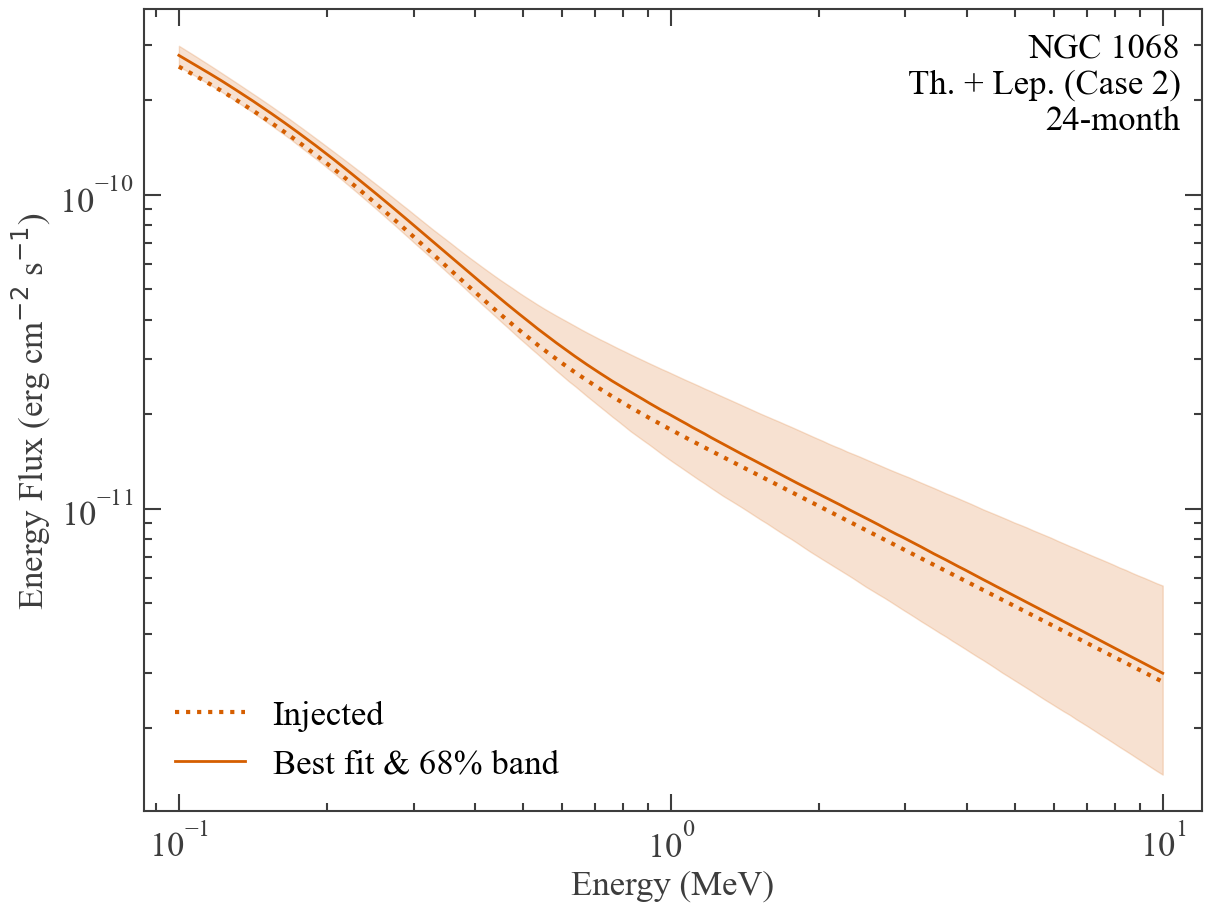

In [11]:
fig_global, ax_global = plt.subplots(figsize=FIGURE_SIZE, constrained_layout=True)
style_axis(ax_global)
draw_global_curves(ax_global)
ax_global.text(0.98, 0.97, "NGC 1068\nTh. + Lep. (Case 2)\n24-month", transform=ax_global.transAxes, ha="right", va="top", fontsize=FONT_SIZE, fontweight="550")
ax_global.legend(handles=[
    plt.Line2D([], [], color="#D55E00", ls=":", lw=3, label="Injected"),
    plt.Line2D([], [], color="#D55E00", lw=2, label="Best fit & 68% band"),
], fontsize=FONT_SIZE, loc="lower left", frameon=False)
global_plot_path = PLOT_DIR / "NGC1068_Case2_CPL_PL_128_24Months_GlobalFit.pdf"
# The global-fit figure is displayed for inspection but intentionally not saved.
plt.show()


# SED


In [12]:
representative_sed = fit_representative_sed(
    source_expectation=source_expectation_24m,
    background_expectation=background_24m, data_histogram=data_24m,
    injected_shape=injected_shape, n_sed_bins=N_SED_BINS,
    energy_min_keV=100.0, energy_max_keV=10000.0,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT, detection_ts=4.0,
)
representative_sed = classify_representative_sed(representative_sed, detection_ts=4.0)

_, ensemble_summary, _, ensemble_summary_file = run_or_load_manifest_sed_ensemble(
    manifest=manifest_24m, source_expectation=source_expectation_24m,
    background_expectation=background_24m, injected_shape=injected_shape,
    n_sed_bins=N_SED_BINS, energy_min_keV=100.0, energy_max_keV=10000.0,
    background_pseudocount=BACKGROUND_PSEUDOCOUNT,
    recompute=SED_ENSEMBLE_RECOMPUTE, detection_ts=4.0,
    expected_seed_count=SED_ENSEMBLE_SEED_COUNT,
)
ensemble_sed = ensemble_summary_to_sed_dataframe(ensemble_summary)

display(representative_sed[["bin_index", "ts_value", "plot_role", "excess_counts"]])
display(ensemble_summary[["bin_index", "ts_median", "plot_role", "fraction_ts_zero"]])


,bin_index,ts_value,plot_role,excess_counts
0,1,505.535669,detection,146687.0
1,2,616.833283,detection,207198.0
2,3,152.013634,detection,91777.0
3,4,32.303034,detection,29282.0
4,5,6.747347,detection,4583.0
5,6,0.531471,upper_limit,1906.0
6,7,1.128340,upper_limit,3715.0
7,8,0.000000,omitted,-2217.0
8,9,0.000000,omitted,942.0
9,10,0.000000,omitted,-82.0


,bin_index,ts_median,plot_role,fraction_ts_zero
0,1,412.931445,detection,0.000000
1,2,488.489956,detection,0.000000
2,3,173.463666,detection,0.000000
3,4,27.558377,detection,0.000000
4,5,4.019308,detection,0.023333
5,6,0.525021,upper_limit,0.230000
6,7,0.027018,upper_limit,0.433333
7,8,0.000000,omitted,0.816667
8,9,0.000000,omitted,0.803333
9,10,0.000000,omitted,0.883333


In [13]:
def plot_sed_dataframe(sed_dataframe, save_path=None):
    roles = sed_dataframe["plot_role"].astype(str)
    detections = sed_dataframe.loc[roles == "detection"]
    upper_limits = sed_dataframe.loc[roles == "upper_limit"]
    def xerr(frame):
        return KEV_TO_MEV*np.vstack([
            frame["e_ref_keV"]-frame["e_min_keV"],
            frame["e_max_keV"]-frame["e_ref_keV"],
        ])
    fig, axis = plt.subplots(figsize=FIGURE_SIZE, constrained_layout=True)
    style_axis(axis); draw_global_curves(axis)
    if not detections.empty:
        y = detections["sed_erg_cm2_s"].to_numpy(float)
        axis.errorbar(
            detections["e_ref_keV"]*KEV_TO_MEV, y, xerr=xerr(detections),
            yerr=np.vstack([
                np.maximum(y-detections["sed_lo_erg_cm2_s"], 0.0),
                np.maximum(detections["sed_hi_erg_cm2_s"]-y, 0.0),
            ]), fmt="o", color="#D55E00", markerfacecolor="white",
            markeredgewidth=1.6, capsize=4, markersize=8,
        )
    if not upper_limits.empty:
        if "sed_ul95_erg_cm2_s" in upper_limits:
            y = upper_limits["sed_ul95_erg_cm2_s"].to_numpy(float)
        elif "sed_ul95_median_erg_cm2_s" in upper_limits:
            y = upper_limits["sed_ul95_median_erg_cm2_s"].to_numpy(float)
        else:
            y = upper_limits["sed_hi_erg_cm2_s"].to_numpy(float)
        axis.errorbar(
            upper_limits["e_ref_keV"]*KEV_TO_MEV, y, xerr=xerr(upper_limits),
            yerr=np.maximum(0.5*y, np.finfo(float).tiny), uplims=True, fmt="v",
            color="#D55E00", markerfacecolor="white", markeredgewidth=1.8,
            elinewidth=2.4, capsize=6, markersize=11,
        )
    axis.text(0.98, 0.97, "NGC 1068\nTh. + Lep. (Case 2)\n24-month", transform=axis.transAxes, ha="right", va="top", fontsize=FONT_SIZE, fontweight="550")
    handles=[
        plt.Line2D([], [], color="#D55E00", ls=":", lw=3, label="Injected"),
        plt.Line2D([], [], color="#D55E00", lw=2, label="Best fit & 68% band"),
        plt.Line2D([], [], color="0.25", marker="o", markerfacecolor="white", linestyle="None", label="COSI SED"),
        plt.Line2D([], [], color="0.25", marker="v", markerfacecolor="white", linestyle="None", label="95% upper limit"),
    ]
    axis.legend(handles=handles, fontsize=FONT_SIZE, loc="lower left", frameon=False)
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)
    return fig, axis


### Plot A — representative median data set

SED values and TS classification use the selected representative seed.


Saved: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC1068_Case2_CPL_PL_128_24Months_SED_RepresentativeMedianDataset.pdf


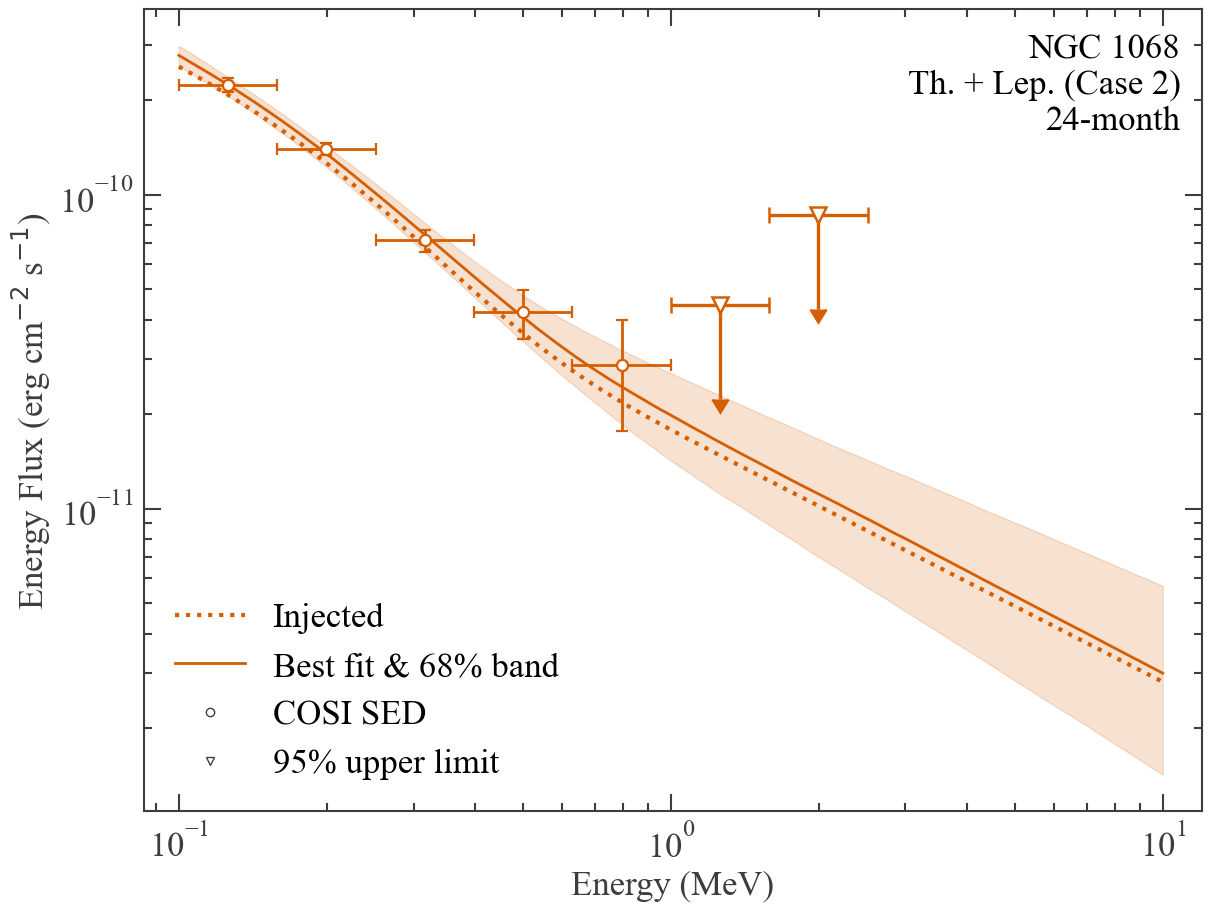

In [14]:
fig_representative, ax_representative = plot_sed_dataframe(
    representative_sed, PLOT_DIR / "NGC1068_Case2_CPL_PL_128_24Months_SED_RepresentativeMedianDataset.pdf",
)
plt.show()


### Plot B — 100-seed median SED

SED values and TS classification use the bin-by-bin ensemble medians.


Saved: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC_Overleaf/Plots/Fluctuate_True/NGC1068_Case2_CPL_PL_128_24Months_SED_100SeedMedianSED.pdf


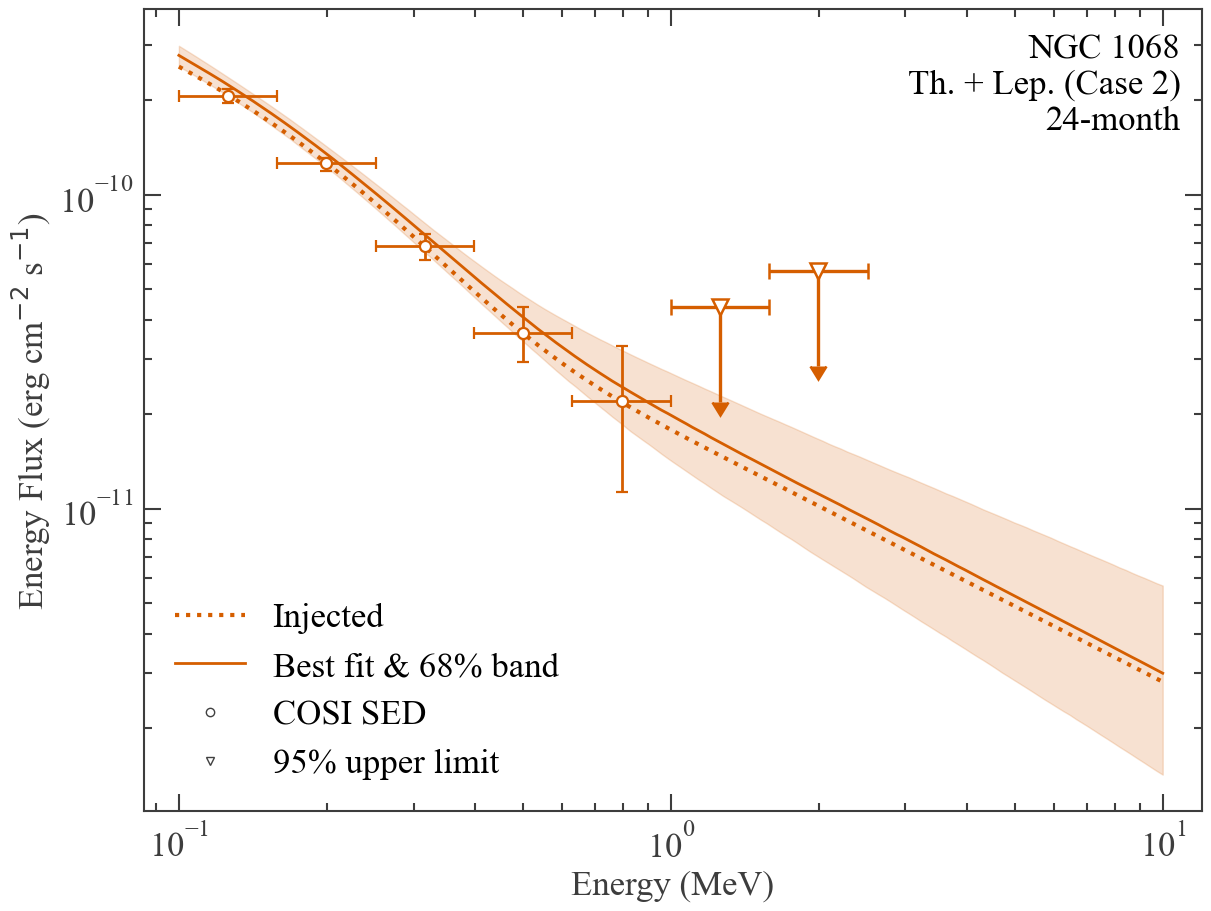

In [15]:
fig_ensemble, ax_ensemble = plot_sed_dataframe(
    ensemble_sed, None,  # Plot B is displayed but intentionally not saved.
)
plt.show()
